# Kurzzeit-Fourier-Transformation
Die Kurzzeit-Fourier-Transformation (Short Time Fourier Transform, STFT) ist einer der grundlegendsten Algorithmen zur Audioanalyse. Sie berechnet das Spektrogramm, in dem die zeitliche und frequenzbezogene Verteilung des analysierten Signals sichtbar wird. Die STFT wird im Folgenden eingefuehrt.


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, '../Basics')
import WaveFileHandling

## Problem:
Angenommen, Sie haben ein Signal $x(n)$ mit ueber die Zeit ansteigender Frequenz (ein sogenannter Sweep).
Ein einfaches Beispiel fuer einen Sweep ist ein Elektromotor, der mit der niedrigsten Drehzahl startet und bis zur hoechsten Drehzahl hochlaeuft.

Eine Darstellung des zugehoerigen Zeitsignals in Gruen ist wegen der hohen Anzahl an Samples schwer zu analysieren.

Eine Darstellung des Betragsspektrums in Blau zeigt den Frequenzbereich des Signals. Leider erhalten Sie keine Information darueber, zu welchem Zeitpunkt welche Frequenz aktiv ist. Es ist nicht moeglich zu entscheiden, ob die Frequenz ueber die Zeit ansteigt oder abfaellt.

Zusaetzlich zu den Darstellungen im Zeitbereich und im Frequenzbereich ist der Sweep als Wave-Datei gespeichert. Hoeren Sie ihn sich zum Beispiel mit der Software Audacity an, um ein Gefuehl dafuer zu bekommen, was ein Sweep ist.


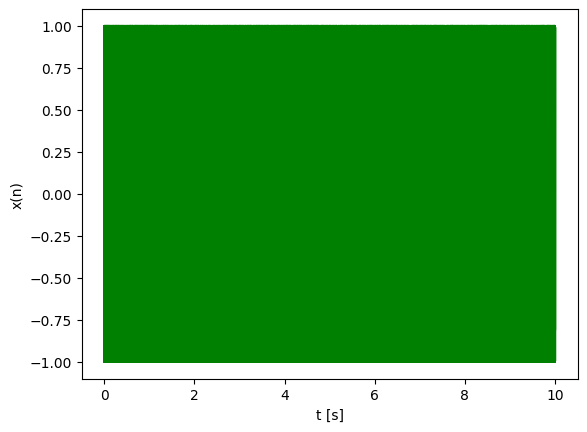

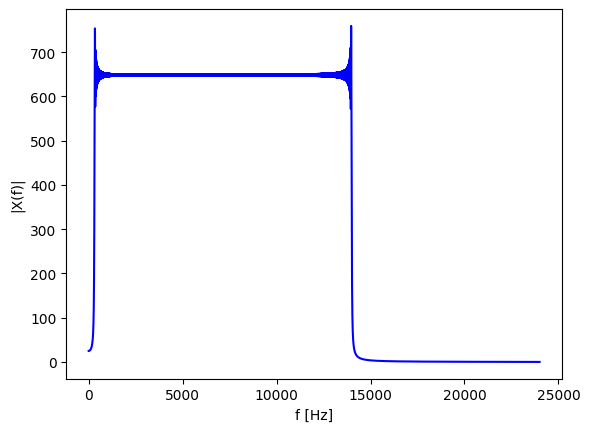

In [52]:
r = 48000
t = np.arange(10*r) / r
f0 = 300
f1 = 14000
psi = (f0+0.5*(f1-f0)/t[-1]*t)*t
x = np.sin(2*np.pi*psi)

WaveFileHandling.WriteWaveAsNumpyArray(x, r, 'sweep.wav')

plt.plot(t, x, 'g')
plt.xlabel('t [s]')
plt.ylabel('x(n)')
plt.show()

X = np.fft.fft(x)
NyquistIndex = int(X.shape[0]/2+1)
f_axis = np.arange(NyquistIndex)/X.shape[0]*r
X = np.abs(X[0:NyquistIndex])
plt.plot(f_axis, X, 'b')
plt.xlabel('f [Hz]')
plt.ylabel('|X(f)|')
plt.show()


## Loesung
Eine lokale Analyse des Signals wuerde die lokalen Signaleigenschaften (dominante Frequenzen) und deren zeitliche Entwicklung sichtbar machen.

Der Algorithmus fuer diese lokale Analyse ist die STFT.

Als erster Schritt wird ein Analysefenster $w(n)$ definiert. In diesem Beispiel wird ein Hann-Fenster verwendet.


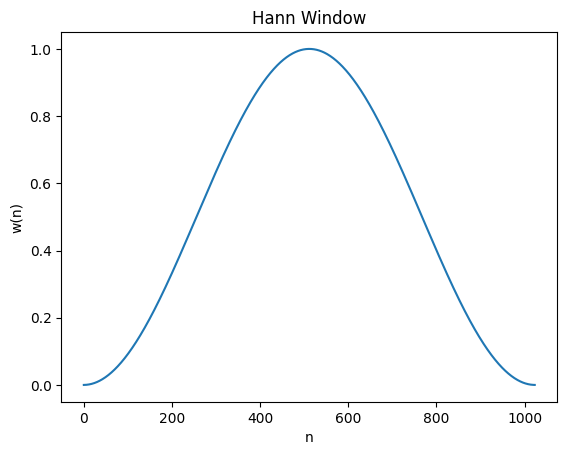

In [53]:
def HannWindow(N):
    return 0.5*(1-np.cos(2*np.pi*(np.arange(N) + 0.5)/N)) # Analysefenster

ws = 2**10 # Fenstergroesse
hs = int(ws/2) # Hopgroesse
w = HannWindow(ws)

plt.plot(w)
plt.xlabel('n')
plt.ylabel('w(n)')
plt.title('Hann-Fenster')
plt.show()


Das Ergebnis der STFT ist ein sogenanntes Spektrogramm. Seine Berechnung wird im Folgenden erklaert:

Das Analysefenster wird elementweise mit den ersten Samples des Signals multipliziert. Das Produkt wird durch die DFT in ein Spektrum transformiert. Das resultierende Spektrum wird in der ersten Spalte des Spektrogramms gespeichert.

Das Analysefenster wird um die sogenannte Hopgroesse verschoben. Wieder wird der entsprechende Bereich des Signals mit dem Analysefenster multipliziert, die DFT wird angewendet und das resultierende Spektrum wird in der zweiten Spalte des Spektrogramms gespeichert.

Wiederholen Sie diesen Algorithmus, bis genug Samples des Eingangssignals analysiert sind.

Dieser Algorithmus wird im Folgenden gezeigt. Die ersten drei Signalbereiche werden nach der Multiplikation mit der Fensterfunktion dargestellt.


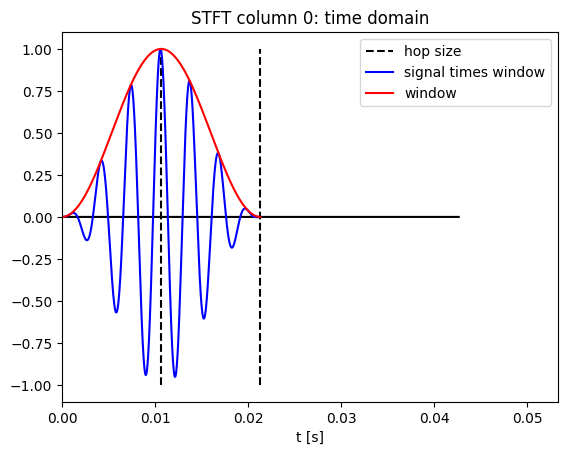

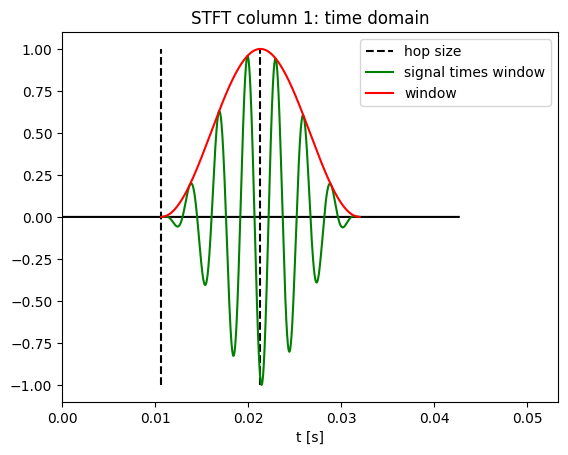

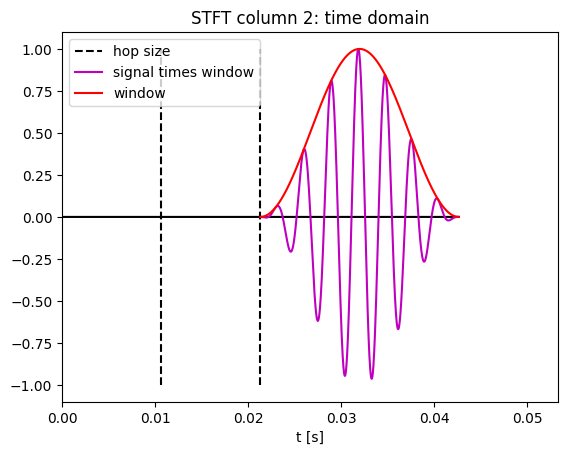

In [54]:
MaxColumnForVisualization = 3
colorvector = 'bgm'
assert MaxColumnForVisualization <= len(colorvector), 'nicht genug Farben fuer die Visualisierung der Spalten'
K = 2*ws # Zero Padding mit Faktor 2 verwenden
NumberOfColumns = int((x.shape[0] - ws) / hs + 1)
NyquistIndex = K // 2 + 1
X = np.zeros((NyquistIndex, NumberOfColumns), dtype = complex)
for column in range(NumberOfColumns):
    idx1 = column * hs
    idx2 = idx1 + ws
    LocalTimeSignal = x[idx1:idx2] * w
    LocalSpectrum = np.fft.fft(LocalTimeSignal, n = K)
    X[:, column] = LocalSpectrum[0:NyquistIndex]
    
    # der folgende Code hat nichts mit der STFT zu tun und dient nur der Visualisierung
    if column < MaxColumnForVisualization:
        t = np.arange(0, (MaxColumnForVisualization-1)*hs+ ws) / r   
        plt.plot(t, np.zeros(t.shape), 'k')
        # Hopgroesse markieren
        for n in range(1, MaxColumnForVisualization):
             plt.plot([n*hs/r, n*hs/r], [-1, 1], 'k--', label='Hopgroesse' if n == 1 else None)
        t = np.arange(idx1, idx2) / r        
        plt.plot(t, LocalTimeSignal, colorvector[column], label = 'Signal mal Fenster')
        plt.plot(t, w, 'r', label='Fenster')
        plt.xlabel('t [s]')
        plt.xlim(0, (MaxColumnForVisualization * hs + ws) / r)
        title = 'STFT-Spalte ' + str(column) + ': Zeitbereich'
        plt.title(title)
        plt.legend()
        plt.show()


Die resultierende Matrix, also das sogenannte Spektrogramm, wird im Folgenden dargestellt. Kleinere Betraege in den Spektren haben eine dunkle Farbe. Hoehere Betraege haben eine hellere Farbe. Durch dieses Farbschema beziehungsweise diese Farbkarte lassen sich die dominanten Frequenzen ueber die Zeit leicht interpretieren.

Das dargestellte Spektrogramm in diesem Beispiel zeigt die ueber die Zeit ansteigende Frequenz (Hinweis: Die Frequenzachse zeigt die niedrigsten Frequenzen im oberen Bereich und die hoechsten Frequenzen im unteren Bereich).

Die zweite Darstellung zeigt die ersten fuenf Spalten des Spektrogramms in unterschiedlichen Farben, um die Zusammenhaenge zwischen der Darstellung des gesamten Spektrogramms und der Darstellung einzelner Spalten zu verdeutlichen.


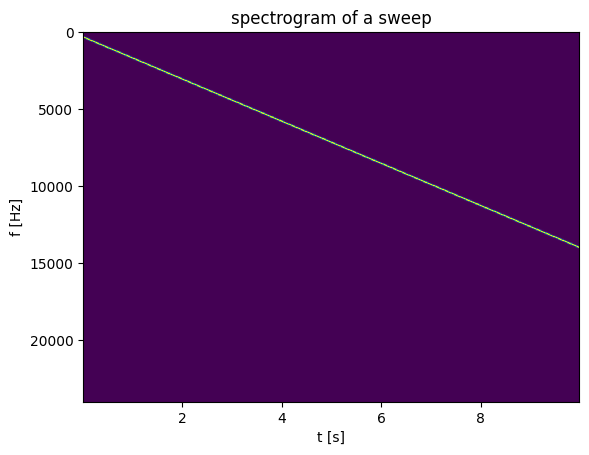

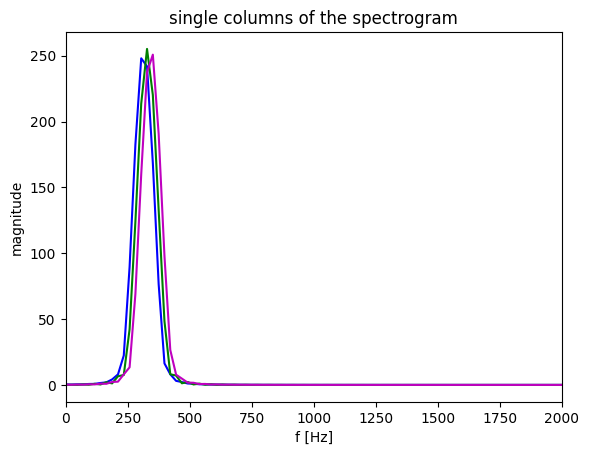

In [55]:
def PlotSpectrogram(X, t, f, PlotSingleColumns = False):
    plt.imshow(X, interpolation='nearest',aspect='auto', extent =[t.min(), t.max(), f.max(), f.min()])
    plt.xlabel('t [s]')
    plt.ylabel('f [Hz]')
    plt.title('Spektrogramm eines Sweeps')
    plt.show()

    if PlotSingleColumns:
        f_vector = np.arange(X.shape[0])*r/K
        for column in range(MaxColumnForVisualization):
            plt.plot(f_vector, X[:, column], colorvector[column])
        plt.xlim(0, 2000)
        plt.xlabel('f [Hz]')
        plt.ylabel('Betrag')
        plt.title('Einzelspalten des Spektrogramms')
        plt.show()

Delta_f = r / K
Delta_t = hs / r
f = np.arange(X.shape[0]) * Delta_f
t = np.arange(X.shape[1]) * Delta_t + Delta_t/2
PlotSpectrogram(np.abs(X), t, f, PlotSingleColumns = True)


## Constant-Overlap-Add-Eigenschaft
Die Fade-In- und Fade-Out-Eigenschaft des Analysefensters konzentriert den Fokus der spektralen Analyse durch die DFT auf die Samples in der Mitte des Analysefensters. Um die Samples am Ende des Analysefensters zu analysieren, wird einfach das naechste Fenster verwendet. Damit durch die aufeinanderfolgende Fensterung keine akustischen Ereignisse verloren gehen, ist es notwendig, dass benachbarte Fenster sich zu einer Konstanten aufsummieren.

Im folgenden Experiment wird untersucht, fuer welche Kombinationen aus Fenstergroesse und Hopgroesse das Hann-Fenster die fuer Analyse und Synthese notwendige Constant-Overlap-Add-Eigenschaft besitzt:


In [56]:
def CheckOverlapAdd(w, OverlapInPercent):
    ws = w.shape[0]
    hs = int((1 - OverlapInPercent / 100) * ws)
    NumberOfAnalysisWindows = 10
    WindowSum = np.zeros((NumberOfAnalysisWindows-1)*hs+ws)
    for n in range(NumberOfAnalysisWindows):
        idx1 = n*hs
        idx2 = idx1 + ws
        WindowSum[idx1:idx2] += w
    MiddlePartOfWindowSum = WindowSum[ws:-ws]
    assert np.std(MiddlePartOfWindowSum) < 1e-2, 'keine konstante Fenstersumme abgesehen von Fade-In- und Fade-Out-Effekten'

hs = 100 # beliebige Hopgroesse
for n in range(7):    
    ws = int(hs * (n+2))
    OverlappInPercent = (1 - hs / ws)*100
    CheckOverlapAdd(HannWindow(ws), OverlapInPercent=OverlappInPercent)
    print('Ueberlappung in Prozent: ' + str(OverlappInPercent) + ' -> Test bestanden')


overlap in percent: 50.0 -> check passed
overlap in percent: 66.66666666666667 -> check passed
overlap in percent: 75.0 -> check passed
overlap in percent: 80.0 -> check passed
overlap in percent: 83.33333333333334 -> check passed
overlap in percent: 85.71428571428572 -> check passed
overlap in percent: 87.5 -> check passed


## Zeit-Frequenz-Aufloesung
Im oben gezeigten Beispiel wird ein Signal mit kontinuierlichen Signaleigenschaften durch die STFT analysiert: ein Sweep.

Im Folgenden wird ein Signal mit zwei kurzen Rauschimpulsen und zwei Sinussen angenommen.

Die beiden Impulse liegen sehr nahe beieinander: $10$ Millisekunden. Deshalb koennen sie nur in einem Spektrogramm mit kurzen Analysefenstern getrennt analysiert werden, zum Beispiel mit einer Fenstergroesse von $480$ Samples.

Die beiden Sinusse haben aehnliche Frequenzen: $4001$ Hz und $4211$ Hz. Sie koennen nur in einem Spektrogramm mit langen Analysefenstern getrennt analysiert werden, was zu einer guten Frequenzaufloesung $\Delta_f$ fuehrt, zum Beispiel mit einer Fenstergroesse von $9600$ Samples.

Diese beiden Bedingungen, gute Zeitaufloesung bei einer Fenstergroesse von $480$ Samples und gute Frequenzaufloesung bei einer Fenstergroesse von $9600$ Samples, koennen nicht gleichzeitig erfuellt werden. Deshalb fuehren kurze Analysefenster zu einer guten Zeitaufloesung, wodurch sich die beiden Rauschimpulse trennen lassen. Lange Analysefenster fuehren dagegen zu einer guten Frequenzaufloesung, wodurch sich die beiden Sinusse trennen lassen. In diesem Fall sind die beiden Impulse im Spektrogramm nicht unterscheidbar.


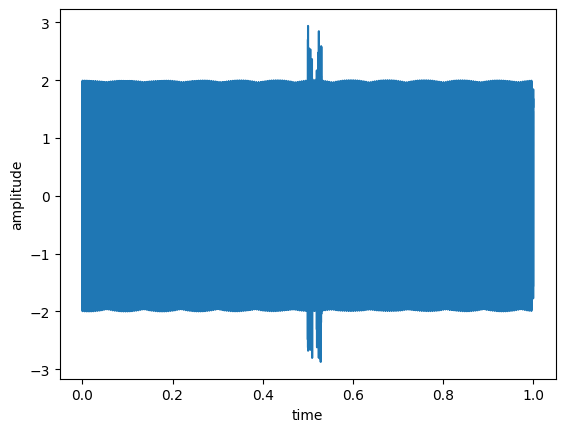

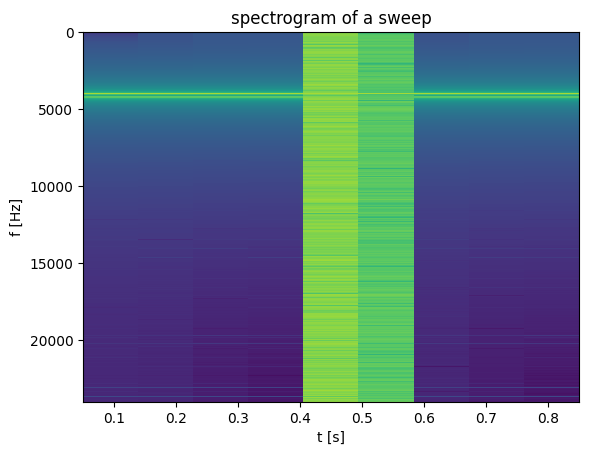

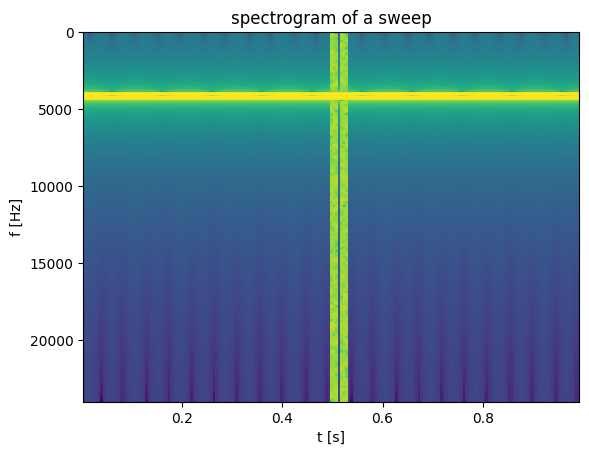

In [57]:
t = np.arange(r)/r
x = np.zeros(t.shape)
# zwei Sinusse mit den angegebenen Frequenzen hinzufuegen
for f in [4001, 4211]:
    phi = f**2 # beliebige Phase
    x += np.sin(2*np.pi*f*t + phi)

# zwei kurze Rauschimpulse hinzufuegen
BurstLengthInMilliseconds = 10
BurstLengthInSamples = int(BurstLengthInMilliseconds * r / 1000)
for n in range(2):
    idx1 = int(t.shape[0]/2 + 2*n*BurstLengthInSamples)
    idx2 = idx1 + BurstLengthInSamples
    x[idx1:idx2] += np.random.rand(BurstLengthInSamples)*2-1

plt.plot(t, x)
plt.xlabel('Zeit')
plt.ylabel('Amplitude')
plt.show()

def Spectrogram(x, WindowSize, FFTLen = None, HopSize = None):
    if HopSize is None:
        HopSize = WindowSize // 2 # 50 % Ueberlappung
    if FFTLen is None:
        FFTLen = WindowSize
    NumberOfColumns = int(np.floor((x.shape[0] - WindowSize) / HopSize) + 1)
    X = np.zeros((FFTLen // 2 + 1, NumberOfColumns), dtype = complex)
    w = HannWindow(WindowSize)
    for column in range(NumberOfColumns):
        idx1 = column * HopSize
        idx2 = idx1 + WindowSize
        x_Block = x[idx1:idx2] * w
        X[:, column] = np.fft.rfft(x_Block, n = FFTLen)
    return X

K = 9600
hs = K // 2
X_9600 = Spectrogram(x, K, K, hs)
Delta_f = r / K
Delta_t = hs / r
f = np.arange(X_9600.shape[0]) * Delta_f
t = np.arange(X_9600.shape[1]) * Delta_t + Delta_t/2
PlotSpectrogram(20*np.log10(np.abs(X_9600)), t, f)

K = 480
hs = K // 2
X_480 = Spectrogram(x, K, K, hs)
Delta_f = r / K
Delta_t = hs / r
f = np.arange(X_480.shape[0]) * Delta_f
t = np.arange(X_480.shape[1]) * Delta_t + Delta_t/2
PlotSpectrogram(20*np.log10(np.abs(X_480)), t, f)


## Zeitaufloesung des menschlichen Ohrs

Die Haarzellen im menschlichen Ohr koennen ungefaehr einmal pro Millisekunde feuern. Dadurch kann die Hopgroesse des menschlichen Ohrs durch diesen Wert angenaehert werden. Fuer normale Audioanalyse durch Software ist diese Hopgroesse des menschlichen Ohrs viel zu fein. Eine gute Faustregel sind Hopgroessen von ungefaehr $10$ Millisekunden fuer Sprachanalyse und ungefaehr $100$ Millisekunden fuer Musikanalyse.


## STFT als Vorverarbeitung
Fuer Audioanalyse, Klassifikation, Transkription und andere Aufgaben ist die STFT ein typisches Eingangsmerkmal fuer neuronale Netze.
Andere Standardverfahren der Vorverarbeitung beginnen ueblicherweise mit der STFT:

### Mel-Spektrogramm
Bei einem Mel-Spektrogramm wird die Frequenzachse des Spektrogramms logarithmisch komprimiert. Dadurch wird die lineare Frequenzachse in eine logarithmische Frequenzachse transformiert, zum Beispiel in die Mel-Achse. Siehe dazu auch [Bark-Skala](../Basics/Bark.ipynb) fuer weitere Informationen zur logarithmischen Frequenzaufloesung des menschlichen Ohrs. Ein Mel-Spektrogramm verwendet typischerweise $24$ logarithmisch verteilte Bandpassfilter, um das Spektrogramm zu komprimieren. Dadurch sollte Sprachverstaendlichkeit weiterhin moeglich sein, wie in [Bark-Skala](../Basics/Bark.ipynb) beschrieben. Zusaetzlich wird durch diese Datenkompression von mehreren hundert linearen Frequenz-Bins auf $24$ logarithmisch verteilte Bandpaesse die Menge an Eingangsdaten fuer die Klassifikationsstufe reduziert, was die Menge der fuer ein erfolgreiches Training eines Klassifikationsalgorithmus notwendigen Trainingsdaten verringert.

### Log-Mel-Spektrogramm
Neben der logarithmischen Frequenzaufloesung nehmen Menschen auch die Lautstaerke von Schallereignissen auf logarithmische Weise wahr, siehe auch [Dezibel](../Basics/Decibel.ipynb) und [SNR](../Basics/SignalToNoiseRatio.ipynb). Deshalb werden die Betraege eines Mel-Spektrogramms haeufig ebenfalls logarithmisch komprimiert, wodurch das Log-Mel-Spektrogramm entsteht.

### Mel-Frequency-Cepstral-Coefficients
Die Mel-Frequency-Cepstral-Coefficients (MFCC) sind Standard-Audiomerkmale fuer die Klassifikation mit kleineren neuronalen Netzen. Mit groesser werdenden Netzen, effizienteren Algorithmen und besserer Hardware wird haeufiger das Log-Mel-Spektrogramm als Vorverarbeitung fuer Audiosignale verwendet.

MFCC werden berechnet, indem eine diskrete Kosinustransformation (DCT) auf die Frequenzachse eines Log-Mel-Spektrogramms angewendet wird und anschliessend die niedrigste Frequenz sowie ein Satz der hoechsten Frequenzen verworfen werden.

Die MFCC sind eng mit dem Quell-Filter-Modell der Sprachproduktion verwandt.

Wegen der spaeteren Verwendung von PyTorch fuer [Klassifikation](../Week11_MachineLearning_Classification/01_Classification.ipynb) werden die Implementierungen dieser Vorverarbeitungsschritte in PyTorch im Folgenden gezeigt.


In [58]:
### https://docs.pytorch.org/audio/main/generated/torchaudio.transforms.MelSpectrogram.html
import torchaudio

waveform, sample_rate = torchaudio.load("../Audio/P501_D_EN_fm_SWB_48k.wav", normalize=True)

### Beispielcode zur Berechnung des Spektrogramms mit PyTorch
transform = torchaudio.transforms.Spectrogram(n_fft = 1024, hop_length = 512)
spectrogram = transform(waveform)

### Beispielcode zur Berechnung des Mel-Spektrogramms mit PyTorch
transform = torchaudio.transforms.MelSpectrogram(sample_rate, n_mels = 40, n_fft = 1024, hop_length = 512)
mel_spectrogram = transform(waveform)

### Beispielcode zur Berechnung der MFCC mit PyTorch
transform = torchaudio.transforms.MFCC(sample_rate, n_mfcc=12, melkwargs={"n_fft": 512, "hop_length": 160, "n_mels": 24, "center": False})
mfcc = transform(waveform)


## Programmieraufgabe
Die inverse Kurzzeit-Fourier-Transformation arbeitet mit dem Overlap-Add-Algorithmus:

Jede Spalte des Spektrogramms wird durch die inverse DFT in den Zeitbereich transformiert. Dieses lokale Zeitsignal $y_\text{block}$ wird an die zu dieser Spalte des Spektrogramms gehoerende Position verschoben. An dieser Position wird $y_\text{block}$ zum Ausgangssignal $y$ addiert.

Wenn die fuer die Analyse verwendeten Fensterfunktionen sich zur Konstanten $1$ aufsummieren, gibt es keinen Fehler zwischen Eingangssignal $x$ und Ausgangssignal $y$. Deshalb ist es wichtig zu wissen, bei welchen Kombinationen aus Fenstergroesse und Hopgroesse sich die Analysefenster zu einer Konstanten aufsummieren.

Die Laenge der FFT (FFTLen) sollte mindestens dann eine Zweierpotenz sein, wenn Sie die FFT auf einem kostenguenstigen Prozessor berechnen. Implementieren Sie die Prozedur NextPowerOf2, die einen ganzzahligen Wert findet, der eine Zweierpotenz ist und groesser oder gleich der Fenstergroesse ist.

Implementieren Sie die Prozedur ISTFT.


In [ ]:
def NextPowerOf2(WindowSize):
    FFTLen = 0
    ### loesung

    ### loesung
    return FFTLen

def GetWindowSize(X, WindowSize):
    ### loesung

    ### loesung
    return WindowSize

def GetHopSize(WindowSize, HopSize):
    ### loesung

    ### loesung
    return HopSize

def GetOutputLength(X, WindowSize, HopSize):
    OutputLength = 0
    ### loesung

    #### loesung
    return OutputLength


def ISTFT(X, WindowSize = None, HopSize = None):
    y = 0
    WindowSize = GetWindowSize(X, WindowSize)
    HopSize = GetHopSize(WindowSize, HopSize)
    y = np.zeros((GetOutputLength(X, WindowSize, HopSize)))
    ### loesung

    ### loesung
    return y
        
import unittest

class TestProgrammingExercise(unittest.TestCase):

    def test_PowerOf2_Log2IsInteger(self):
        x = np.random.randint(100) + 1
        y = NextPowerOf2(x)
        z = np.log2(y)
        self.assertAlmostEqual(int(z), z, 1e-3)

    def test_PowerOf2_1(self):
        x = np.random.randint(100) + 1
        y = NextPowerOf2(x)
        self.assertGreaterEqual(y, x)

    def test_PowerOf2_2(self):
        x = np.random.randint(100) + 1
        y = NextPowerOf2(x)
        self.assertGreaterEqual(x, y/2)

    def test_WindowSizeNone(self):
        X = np.random.randn(47, 100)
        ws = GetWindowSize(X, None)
        self.assertEqual(ws, 92)
        X = np.random.randn(53, 100)
        ws = GetWindowSize(X, None)
        self.assertEqual(ws, 104)
        
    def test_WindowSizeDefined(self):
        X = np.random.randn(47, 100)
        WindowSize = np.random.randint(500)
        self.assertEqual(GetWindowSize(X, WindowSize), WindowSize)

    def test_HopSizeNone(self):
        hs = GetHopSize(512, None)
        self.assertEqual(hs, 256)
        hs = GetHopSize(1000, None)
        self.assertEqual(hs, 500)
        
    def test_HopSizeDefined(self):
        HopSize = np.random.randint(500)
        self.assertEqual(GetHopSize(np.random.randint(1000), HopSize), HopSize)
    
    def test_OutputLength(self):
        ws = 1000
        hs = ws // 2
        FFTLen = ws
        x = np.random.randn(50000)
        X = Spectrogram(x, ws, FFTLen, hs)
        y = ISTFT(X)      
        self.assertEqual(x.shape[0], y.shape[0])

    def test_ISTFT(self):
        ws = 1000
        hs = ws // 2
        FFTLen = ws
        x = np.random.randn(50000)
        X = Spectrogram(x, ws, FFTLen, hs)
        y = ISTFT(X)
        x = x[:y.shape[0]]
        Offset = ws - hs
        x = x[Offset:-Offset]
        y = y[Offset:-Offset]       
        self.assertGreater(10*np.log10(np.sum(x**2) / np.sum((x-y)**2)), 200)

    def test_ISTFT_hs(self):
        hs = 500
        ws = hs * (np.random.randint(4) + 2)
        FFTLen = ws
        x = np.random.randn(50000)
        X = Spectrogram(x, ws, FFTLen, hs)
        y = ISTFT(X, ws, hs)
        x = x[:y.shape[0]]
        Offset = ws - hs
        x = x[Offset:-Offset]
        y = y[Offset:-Offset]
        a = np.sum(x*y)/np.sum(y**2)
        self.assertGreater(10*np.log10(np.sum(x**2) / np.sum((x-a*y)**2)), 200)

    def test_ISTFT_FFTLen(self):
        hs = 500
        ws = hs * (np.random.randint(4) + 2)
        FFTLen = NextPowerOf2(ws + np.random.randint(ws))
        x = np.random.randn(50000)
        X = Spectrogram(x, ws, FFTLen, hs)
        y = ISTFT(X, ws, hs)
        x = x[:y.shape[0]]
        Offset = ws - hs
        x = x[Offset:-Offset]
        y = y[Offset:-Offset]
        a = np.sum(x*y)/np.sum(y**2)
        self.assertGreater(10*np.log10(np.sum(x**2) / np.sum((x-a*y)**2)), 200)

    def test_ISTFT_CorrectScaling(self):
        hs = 500
        ws = hs * (np.random.randint(4) + 2)
        FFTLen = NextPowerOf2(ws + np.random.randint(ws))
        x = np.random.randn(50000)
        X = Spectrogram(x, ws, FFTLen, hs)
        y = ISTFT(X, ws, hs)
        x = x[:y.shape[0]]
        Offset = ws - hs
        x = x[Offset:-Offset]
        y = y[Offset:-Offset]
        self.assertGreater(10*np.log10(np.sum(x**2) / np.sum((x-y)**2)), 200)
    
unittest.main(argv=[''], verbosity=2, exit=False)


test_HopSizeDefined (__main__.TestProgrammingExercise.test_HopSizeDefined) ... ok
test_HopSizeNone (__main__.TestProgrammingExercise.test_HopSizeNone) ... ok
test_ISTFT (__main__.TestProgrammingExercise.test_ISTFT) ... ok
test_ISTFT_CorrectScaling (__main__.TestProgrammingExercise.test_ISTFT_CorrectScaling) ... ok
test_ISTFT_FFTLen (__main__.TestProgrammingExercise.test_ISTFT_FFTLen) ... ok
test_ISTFT_hs (__main__.TestProgrammingExercise.test_ISTFT_hs) ... ok
test_OutputLength (__main__.TestProgrammingExercise.test_OutputLength) ... ok
test_PowerOf2_1 (__main__.TestProgrammingExercise.test_PowerOf2_1) ... ok
test_PowerOf2_2 (__main__.TestProgrammingExercise.test_PowerOf2_2) ... ok
test_PowerOf2_Log2IsInteger (__main__.TestProgrammingExercise.test_PowerOf2_Log2IsInteger) ... ok
test_WindowSizeDefined (__main__.TestProgrammingExercise.test_WindowSizeDefined) ... ok
test_WindowSizeNone (__main__.TestProgrammingExercise.test_WindowSizeNone) ... ok

-----------------------------------------

## Klausurvorbereitung

1) Ein Audiosignal mit einer Laenge von $3$ Sekunden hat eine Abtastrate von $r=16$ kHz. Die Frequenzaufloesung $\Delta f$ soll besser als $10$ Hz sein. Die Zeitaufloesung soll besser als $50$ Spektren pro Sekunde sein. Die Ueberlappung zweier benachbarter Fenster betraegt $50$ \%. Bestimmen Sie die minimalen Werte von $K$ und $N$. Ist Zero Padding notwendig? Bestimmen Sie den Speicherbedarf dieses Spektrogramms, wenn jeder reellwertige Parameter 4 Byte und jeder komplexwertige Parameter 8 Byte Speicher benoetigt.

2) Welche Aussage ist gemaess der oben dargestellten Spektrogramme richtig: Je kleiner die Fenstergroesse, desto besser ist die Zeitaufloesung eines Spektrogramms. Je groesser die Fenstergroesse, desto besser ist die Zeitaufloesung eines Spektrogramms.

3) Welche Aussage ist gemaess der oben dargestellten Spektrogramme richtig: Je kleiner die Fenstergroesse, desto besser ist die Frequenzaufloesung eines Spektrogramms. Je groesser die Fenstergroesse, desto besser ist die Frequenzaufloesung eines Spektrogramms.

4) Ein Audiosignal mit einer Laenge von $5$ Sekunden wird mit einer STFT analysiert. Die Fenstergroesse beziehungsweise Blockgroesse ist $N=100$ ms. Die Ueberlappung betraegt $75$ \%. Wie viele Bloecke werden analysiert?

5) Ein Audiosignal mit einer Laenge von $5$ Sekunden wird mit einer STFT analysiert. Die Hopgroesse entspricht der Zeitaufloesung des menschlichen Ohrs. Die Spektren werden auf die Frequenzaufloesung des menschlichen Ohrs transformiert. Der im Spektrogramm gespeicherte Frequenzbereich ist $0\leq b \leq 24$ Bark. Wie viele Werte sind im Spektrogramm gespeichert?

6) Eine Fensterfunktion ist definiert durch $w(n)=\left(0.5-0.5\cdot\cos\left(2\pi\frac{n+0.5}{N}\right)\right)^\alpha$ mit $0\leq n<N$ und $0\leq\alpha$. Welche Hopgroesse fuehrt unabhaengig vom Parameter $\alpha$ zu einem konstanten Overlap Add? Fuer welches $\alpha$ ist $w(n)$ gleich dem Hann-Fenster?


## Zusammenfassung
Nach der Bearbeitung dieses Jupyter-Notebooks sollten Sie die folgenden Themen erklaeren koennen:

- Was ist die Motivation fuer die Verwendung einer STFT zur Analyse?
- Was ist der Vorteil eines Constant-Overlap-Add-Szenarios?
- Wie haengen Fenstergroesse, Hopgroesse und das verwendete Fenster zusammen?
- Was sind Zeitaufloesung und Frequenzaufloesung?
